# Importing Libraries 

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report


In [28]:
base_dir = Path('../artifacts')
PROCESSED_DIR = base_dir / 'processed_data'
MODEL_DIR = base_dir / 'models'
FIGURE_DIR = base_dir / 'figures'
FEATURE_DIR = base_dir / 'features'
METRICS_DIR     = base_dir / 'metrics'       
INTERIM_DIR     = base_dir / 'interim_data'  
PREDICTIONS_DIR = base_dir / 'predictions'



directories = [
    PROCESSED_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    FEATURE_DIR,
    METRICS_DIR,
    INTERIM_DIR,
    PREDICTIONS_DIR
]


for path in directories:
    path.mkdir(parents=True, exist_ok=True)
 

# Loading the Data

In [3]:
df = pd.read_csv(f'{PROCESSED_DIR}/dc_features.csv', parse_dates=['date'])
print(df.shape)
print(df.dtypes)

(49233, 23)
date                        datetime64[us]
home_team                              str
away_team                              str
home_goals                         float64
away_goals                         float64
home_win                             int64
away_win                             int64
draw                                 int64
goal_diff                          float64
result                               int64
is_competitive                        bool
home_dc_attack_strength            float64
home_dc_defense_strength           float64
away_dc_attack_strength            float64
away_dc_defense_strength           float64
dc_attack_diff                     float64
dc_defense_diff                    float64
home_dc_weight_sum                 float64
away_dc_weight_sum                 float64
elo_diff                           float64
neutral                              int64
home_is_host                         int64
home_tournament_stage                int64

In [4]:
df.head()

,date,home_team,away_team,home_goals,away_goals,home_win,away_win,draw,goal_diff,result,...,away_dc_attack_strength,away_dc_defense_strength,dc_attack_diff,dc_defense_diff,home_dc_weight_sum,away_dc_weight_sum,elo_diff,neutral,home_is_host,home_tournament_stage
0,1872-11-30,Scotland,England,0.0,0.0,0,0,1,0.0,1,...,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0,0,0
1,1873-03-08,England,Scotland,4.0,2.0,1,0,0,2.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,5.602600,0,0,0
2,1874-03-07,Scotland,England,2.0,1.0,1,0,0,1.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,-26.754938,0,0,0
3,1875-03-06,England,Scotland,2.0,2.0,0,0,1,0.0,1,...,1.0,1.0,0.0,0.0,0.0,0.0,10.909891,0,0,0
4,1876-03-04,Scotland,England,3.0,0.0,1,0,0,3.0,0,...,1.0,1.0,0.0,0.0,0.0,0.0,-4.733783,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49233 entries, 0 to 49232
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      49233 non-null  datetime64[us]
 1   home_team                 49233 non-null  str           
 2   away_team                 49233 non-null  str           
 3   home_goals                49233 non-null  float64       
 4   away_goals                49233 non-null  float64       
 5   home_win                  49233 non-null  int64         
 6   away_win                  49233 non-null  int64         
 7   draw                      49233 non-null  int64         
 8   goal_diff                 49233 non-null  float64       
 9   result                    49233 non-null  int64         
 10  is_competitive            49233 non-null  bool          
 11  home_dc_attack_strength   49233 non-null  float64       
 12  home_dc_defense_strength  492

# Feature Columns 

In [6]:
META_COLS   = ['date', 'home_team', 'away_team']
TARGET_COLS = ['home_goals', 'away_goals', 'home_win', 'draw', 'away_win', 'result']
 
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]
print(f"\nFeatures used: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features used: 14
['goal_diff', 'is_competitive', 'home_dc_attack_strength', 'home_dc_defense_strength', 'away_dc_attack_strength', 'away_dc_defense_strength', 'dc_attack_diff', 'dc_defense_diff', 'home_dc_weight_sum', 'away_dc_weight_sum', 'elo_diff', 'neutral', 'home_is_host', 'home_tournament_stage']


# Train / Valid Split 

In [7]:
if 'is_competitive' not in df.columns:
    df['is_competitive'] = True
 
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()
 
train = train_df[train_df['date'] <  '2024-01-01'].copy()
valid = train_df[train_df['date'] >= '2024-01-01'].copy()
 
print(f"\nTrain : {len(train):,} matches  ({train['date'].dt.year.min()}–{train['date'].dt.year.max()})")
print(f"Valid : {len(valid):,} matches  ({valid['date'].dt.year.min()}–{valid['date'].dt.year.max()})")


Train : 14,855 matches  (2000–2023)
Valid : 1,776 matches  (2024–2026)


# Build Team Index 

In [8]:
all_teams  = sorted(set(train['home_team']) | set(train['away_team']))
team_index = {team: i for i, team in enumerate(all_teams)}
n_teams    = len(all_teams)
 
print(f"\nTotal teams in training set: {n_teams}")


Total teams in training set: 280


# Recency Weights (Exponential Decay)

In [9]:
def compute_weights(dates, reference_date, half_life_days=180.0):
    lam      = np.log(2) / half_life_days
    days_ago = (reference_date - dates).dt.days.values
    return np.exp(-lam * days_ago)
 
 
reference_date  = train['date'].max()
train           = train.copy()
train['weight'] = compute_weights(train['date'], reference_date)
 
print(f"\nReference date for weights : {reference_date.date()}")
print(f"Weight range               : {train['weight'].min():.4f} – {train['weight'].max():.4f}")


Reference date for weights : 2023-12-02
Weight range               : 0.0000 – 1.0000


# Dixon-Coles Low-Score Correction 

In [10]:
 
def dc_correction(home_goals, away_goals, lambda_h, lambda_a, rho):
    if home_goals == 0 and away_goals == 0:
        return 1 - lambda_h * lambda_a * rho
    elif home_goals == 0 and away_goals == 1:
        return 1 + lambda_h * rho
    elif home_goals == 1 and away_goals == 0:
        return 1 + lambda_a * rho
    elif home_goals == 1 and away_goals == 1:
        return 1 - rho
    return 1.0

# Parameter Layout

In [11]:
def unpack_params(params, n_teams):
    attack   = params[:n_teams]
    defense  = params[n_teams:2 * n_teams]
    home_adv = params[2 * n_teams]
    rho      = params[2 * n_teams + 1]
    return attack, defense, home_adv, rho

# Negative Log-Likelihood 

In [12]:
# ── Pre-compute index arrays ONCE (outside the NLL function) ──
home_idx = np.array([team_index.get(t, -1) for t in train['home_team']])
away_idx = np.array([team_index.get(t, -1) for t in train['away_team']])
home_goals_arr = train['home_goals'].values.astype(int)
away_goals_arr = train['away_goals'].values.astype(int)
weights_arr    = train['weight'].values

# Mask out any rows where team is not in index
valid_mask = (home_idx >= 0) & (away_idx >= 0)
home_idx       = home_idx[valid_mask]
away_idx       = away_idx[valid_mask]
home_goals_arr = home_goals_arr[valid_mask]
away_goals_arr = away_goals_arr[valid_mask]
weights_arr    = weights_arr[valid_mask]

In [13]:
def neg_log_likelihood(params, home_idx, away_idx,
                        home_goals_arr, away_goals_arr,
                        weights_arr, n_teams):
    attack, defense, home_adv, rho = unpack_params(params, n_teams)

    # Vectorised expected goals — no loop
    lambda_h = np.exp(attack[home_idx] - defense[away_idx] + home_adv)
    lambda_a = np.exp(attack[away_idx] - defense[home_idx])

    # Vectorised Poisson log-probabilities
    log_p_h = poisson.logpmf(home_goals_arr, lambda_h)
    log_p_a = poisson.logpmf(away_goals_arr, lambda_a)

    # Vectorised DC correction (tau)
    tau = np.ones(len(home_goals_arr))

    m00 = (home_goals_arr == 0) & (away_goals_arr == 0)
    m01 = (home_goals_arr == 0) & (away_goals_arr == 1)
    m10 = (home_goals_arr == 1) & (away_goals_arr == 0)
    m11 = (home_goals_arr == 1) & (away_goals_arr == 1)

    tau[m00] = 1 - lambda_h[m00] * lambda_a[m00] * rho
    tau[m01] = 1 + lambda_h[m01] * rho
    tau[m10] = 1 + lambda_a[m10] * rho
    tau[m11] = 1 - rho

    # Guard against log(0)
    valid = tau > 0
    log_tau = np.where(valid, np.log(np.maximum(tau, 1e-10)), 0.0)

    total_ll = (weights_arr * (log_p_h + log_p_a + log_tau)).sum()
    return -total_ll

# Fitting the Model (Maximum Likelihood)

In [14]:
params_init = np.concatenate([
    np.zeros(n_teams),   # attack
    np.zeros(n_teams),   # defense
    [0.3],               # home_advantage
    [-0.1],              # rho
])
 
bounds = (
    [(None, None)] * n_teams +
    [(None, None)] * n_teams +
    [(None, None)]           +
    [(-0.99, 0.0)]
)
 
constraints = [
    {'type': 'eq', 'fun': lambda p: p[:n_teams].sum()},
    {'type': 'eq', 'fun': lambda p: p[n_teams:2 * n_teams].sum()},
]
 
print("\nFitting Dixon-Coles model via Maximum Likelihood...")

 
result = minimize(
    neg_log_likelihood,
    params_init,
    args=(home_idx, away_idx, home_goals_arr, away_goals_arr, weights_arr, n_teams),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-10, 'disp': True},
)
 
print(f"\nOptimisation converged : {result.success}")
print(f"Message                : {result.message}")
print(f"Final NLL              : {result.fun:.4f}")
 
attack_fit, defense_fit, home_adv_fit, rho_fit = unpack_params(result.x, n_teams)
 
print(f"\nFitted home advantage  : {home_adv_fit:.4f}")
print(f"Fitted rho (DC corr.)  : {rho_fit:.4f}  (negative = draws boosted)")


Fitting Dixon-Coles model via Maximum Likelihood...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1699.3544541957199
            Iterations: 972
            Function evaluations: 547972
            Gradient evaluations: 972

Optimisation converged : True
Message                : Optimization terminated successfully
Final NLL              : 1699.3545

Fitted home advantage  : 0.2320
Fitted rho (DC corr.)  : -0.0200  (negative = draws boosted)


# Team Strength Table

In [15]:
df_strength = pd.DataFrame({
    'team':    all_teams,
    'attack':  attack_fit,
    'defense': defense_fit,
}).sort_values('attack', ascending=False).reset_index(drop=True)
 
print("\n Top 15 Attack Strength")
print(df_strength.head(15).to_string(index=False))
 
print("\n Top 15 Defense Strength (lower = better)")
print(df_strength.sort_values('defense').head(15).to_string(index=False))
 


 Top 15 Attack Strength
       team   attack  defense
     France 1.665192 1.290071
    Germany 1.579097 0.885589
    Uruguay 1.480802 1.354969
   Portugal 1.474195 1.665440
    England 1.408854 1.384347
      Spain 1.394274 1.536394
    Belgium 1.386333 1.334701
  Argentina 1.341088 1.637975
Netherlands 1.321045 0.978113
      Italy 1.317071 0.974523
     Brazil 1.216112 1.161144
    Austria 1.186498 0.982271
Switzerland 1.184010 0.606730
    Morocco 1.169199 1.410185
   Scotland 1.158268 0.841872

 Top 15 Defense Strength (lower = better)
                    team    attack   defense
          American Samoa -4.636575 -5.225006
                   Tonga -3.950487 -4.431901
Northern Mariana Islands -4.206144 -4.354880
            Cook Islands -4.261363 -4.256737
                  Tuvalu -3.239220 -4.136557
                 Vanuatu -2.760154 -2.992935
        Papua New Guinea -3.162749 -2.905033
                   Samoa -3.180622 -2.810784
                    Fiji -2.277809 -2.775786
  

# Predicting on Validation Set

In [16]:

MAX_GOALS = 10
 
def predict_dc(home_team, away_team, is_neutral=False):
    i = team_index.get(home_team)
    j = team_index.get(away_team)
 
    if i is None or j is None:
        missing = [t for t, idx in [(home_team, i), (away_team, j)] if idx is None]
        raise ValueError(f"Unknown team(s): {missing}")
 
    h_adv    = 0.0 if is_neutral else home_adv_fit
    lambda_h = np.exp(attack_fit[i] - defense_fit[j] + h_adv)
    lambda_a = np.exp(attack_fit[j] - defense_fit[i])
 
    score_matrix = np.zeros((MAX_GOALS, MAX_GOALS))
    for hg in range(MAX_GOALS):
        for ag in range(MAX_GOALS):
            p_h  = poisson.pmf(hg, lambda_h)
            p_a  = poisson.pmf(ag, lambda_a)
            tau  = dc_correction(hg, ag, lambda_h, lambda_a, rho_fit)
            score_matrix[hg, ag] = max(p_h * p_a * tau, 0)
 
    score_matrix /= score_matrix.sum()
 
    p_home_win = np.tril(score_matrix, k=-1).sum()
    p_draw     = np.trace(score_matrix)
    p_away_win = np.triu(score_matrix, k=1).sum()
 
    return {
        'lambda_home':   round(lambda_h, 4),
        'lambda_away':   round(lambda_a, 4),
        'prob_home_win': round(p_home_win, 4),
        'prob_draw':     round(p_draw,     4),
        'prob_away_win': round(p_away_win, 4),
        'score_matrix':  score_matrix,
    }
 
 
print("\nGenerating predictions on validation set...")
 
records = []
for row in valid.itertuples(index=False):
    try:
        pred = predict_dc(row.home_team, row.away_team,
                          is_neutral=bool(row.neutral))
        records.append({
            'date':            row.date,
            'home_team':       row.home_team,
            'away_team':       row.away_team,
            'home_goals':      row.home_goals,
            'away_goals':      row.away_goals,
            'result':          row.result,
            'pred_home_goals': pred['lambda_home'],
            'pred_away_goals': pred['lambda_away'],
            'prob_home_win':   pred['prob_home_win'],
            'prob_draw':       pred['prob_draw'],
            'prob_away_win':   pred['prob_away_win'],
        })
    except ValueError:
        continue
 
valid_preds = pd.DataFrame(records)
print(f"Predictions generated : {len(valid_preds):,} / {len(valid):,} matches")
 
print("\nSample predictions:")
print(valid_preds[[
    'date', 'home_team', 'away_team',
    'home_goals', 'pred_home_goals',
    'away_goals', 'pred_away_goals'
]].head(10).to_string(index=False))


Generating predictions on validation set...
Predictions generated : 1,774 / 1,776 matches

Sample predictions:
      date            home_team         away_team  home_goals  pred_home_goals  away_goals  pred_away_goals
2024-01-12                Qatar           Lebanon         3.0           1.7767         0.0           0.4746
2024-01-13                China        Tajikistan         0.0           1.5251         0.0           1.3982
2024-01-13            Australia             India         2.0           2.0688         0.0           0.2497
2024-01-13           Uzbekistan             Syria         0.0           2.1439         0.0           0.4528
2024-01-13          Ivory Coast     Guinea-Bissau         2.0           1.1062         0.0           0.3518
2024-01-14              Nigeria Equatorial Guinea         1.0           2.4812         1.0           1.0054
2024-01-14                Japan           Vietnam         4.0           1.3620         2.0           0.1826
2024-01-14              

# Goal Prediction Metrics

In [17]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
y_valid_home = valid_preds['home_goals']
y_valid_away = valid_preds['away_goals']
 
mae_home  = mean_absolute_error(y_valid_home, valid_preds['pred_home_goals'])
mae_away  = mean_absolute_error(y_valid_away, valid_preds['pred_away_goals'])
rmse_home = rmse(y_valid_home, valid_preds['pred_home_goals'])
rmse_away = rmse(y_valid_away, valid_preds['pred_away_goals'])
 
print("\n Goal Prediction Metrics ")
print(f"  Home goals  →  MAE: {mae_home:.4f}  |  RMSE: {rmse_home:.4f}")
print(f"  Away goals  →  MAE: {mae_away:.4f}  |  RMSE: {rmse_away:.4f}")
 
print(f"\n  Mean pred home : {valid_preds['pred_home_goals'].mean():.3f}  (actual: {y_valid_home.mean():.3f})")
print(f"  Mean pred away : {valid_preds['pred_away_goals'].mean():.3f}  (actual: {y_valid_away.mean():.3f})")
 
 



 Goal Prediction Metrics 
  Home goals  →  MAE: 1.0836  |  RMSE: 1.5690
  Away goals  →  MAE: 0.9229  |  RMSE: 1.4588

  Mean pred home : 1.496  (actual: 1.589)
  Mean pred away : 1.208  (actual: 1.156)


# Scatter — Predicted vs Actual Goals

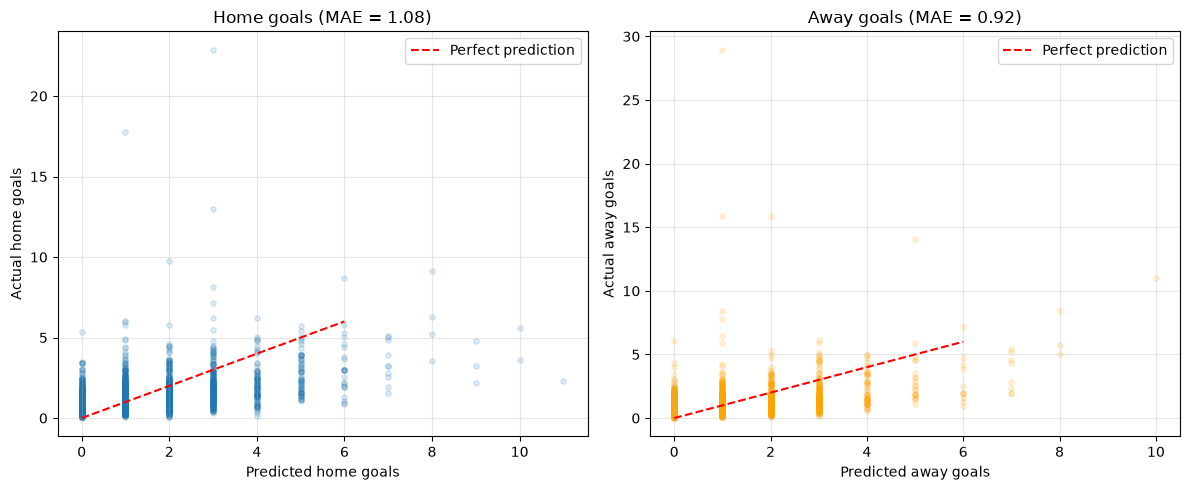

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(y_valid_home, valid_preds['pred_home_goals'], alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Predicted home goals')
axes[0].set_ylabel('Actual home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].scatter(y_valid_away, valid_preds['pred_away_goals'], alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Predicted away goals')
axes[1].set_ylabel('Actual away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

# Outcome Evaluation

In [19]:
def predict_outcome(p_home, p_draw, p_away, draw_threshold=0.28):
    """
    0 = Home Win, 1 = Draw, 2 = Away Win
    If draw probability exceeds threshold predict draw.
    Otherwise take argmax of home/away.
    """
    if p_draw >= draw_threshold:
        return 1
    return 0 if p_home >= p_away else 2

In [20]:
def evaluate_outcome(valid, draw_threshold=0.28):
    """Full evaluation block: accuracy + confusion matrix + classification report."""
    valid = valid.copy()
    valid['pred_result'] = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'],
            draw_threshold
        ), axis=1
    )
 
    accuracy = (valid['pred_result'] == valid['result']).mean()
    print(f"\n Outcome Accuracy (draw_threshold={draw_threshold:.2f}) ")
    print(f"  Correct outcome predicted: {accuracy:.2%}")
 
    cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
    print("\n Confusion Matrix (rows=actual, cols=predicted)")
    print(pd.DataFrame(
        cm,
        index  =['Actual HW', 'Actual Draw', 'Actual AW'],
        columns=['Pred HW',   'Pred Draw',   'Pred AW']
    ))
 
    print("\n Classification Report ")
    print(classification_report(
        valid['result'], valid['pred_result'],
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        zero_division=0
    ))

In [21]:

  
# Default argmax
print("=" * 60)
print("DEFAULT: argmax ")
print("=" * 60)
 
valid_preds['pred_result'] = valid_preds[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1)
valid_preds['pred_result'] = valid_preds['pred_result'].map({
    'prob_home_win': 0,
    'prob_draw':     1,
    'prob_away_win': 2,
})
 
accuracy = (valid_preds['pred_result'] == valid_preds['result']).mean()
print(f"\n  Correct outcome predicted: {accuracy:.2%}")
 
cm = confusion_matrix(valid_preds['result'], valid_preds['pred_result'], labels=[0, 1, 2])
print("\n Confusion Matrix ")
print(pd.DataFrame(
    cm,
    index  =['Actual HW', 'Actual Draw', 'Actual AW'],
    columns=['Pred HW',   'Pred Draw',   'Pred AW']
))
print("\n Classification Report ")
print(classification_report(
    valid_preds['result'], valid_preds['pred_result'],
    target_names=['HomeWin', 'Draw', 'AwayWin'],
    zero_division=0
))
 
 

DEFAULT: argmax 

  Correct outcome predicted: 58.51%

 Confusion Matrix 
             Pred HW  Pred Draw  Pred AW
Actual HW        635         48      141
Actual Draw      217         42      154
Actual AW        139         37      361

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.64      0.77      0.70       824
        Draw       0.33      0.10      0.16       413
     AwayWin       0.55      0.67      0.61       537

    accuracy                           0.59      1774
   macro avg       0.51      0.51      0.49      1774
weighted avg       0.54      0.59      0.54      1774



In [22]:
# Threshold tuning
print("\n" + "=" * 60)
print("TUNING: Find best draw threshold")
print("=" * 60)
 
thresholds = np.arange(0.20, 0.45, 0.01)
results    = []
 
for thresh in thresholds:
    preds = valid_preds.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh
        ), axis=1
    )
    acc       = (preds == valid_preds['result']).mean()
    draw_rate = (preds == 1).mean()
    results.append({
        'threshold':      round(thresh, 2),
        'accuracy':       round(acc, 4),
        'pred_draw_rate': round(draw_rate, 4),
    })
 
df_thresh   = pd.DataFrame(results)
best_row    = df_thresh.loc[df_thresh['accuracy'].idxmax()]
best_thresh = best_row['threshold']
best_acc    = best_row['accuracy']
 
print(f"\n  Actual draw rate in validation : {(valid_preds['result'] == 1).mean():.2%}")
print(f"\n  Best threshold : {best_thresh:.2f}")
print(f"  Best accuracy  : {best_acc:.2%}")
print(f"\n  Threshold scan:")
print(df_thresh.to_string(index=False))
 


TUNING: Find best draw threshold

  Actual draw rate in validation : 23.28%

  Best threshold : 0.42
  Best accuracy  : 59.24%

  Threshold scan:
 threshold  accuracy  pred_draw_rate
      0.20    0.4464          0.6545
      0.21    0.4583          0.6251
      0.22    0.4741          0.5817
      0.23    0.4899          0.5423
      0.24    0.5073          0.4983
      0.25    0.5180          0.4605
      0.26    0.5220          0.4087
      0.27    0.5327          0.3563
      0.28    0.5457          0.3162
      0.29    0.5581          0.2830
      0.30    0.5660          0.2492
      0.31    0.5676          0.2249
      0.32    0.5727          0.2001
      0.33    0.5761          0.1787
      0.34    0.5834          0.1437
      0.35    0.5851          0.1240
      0.36    0.5874          0.1094
      0.37    0.5834          0.0930
      0.38    0.5851          0.0784
      0.39    0.5891          0.0676
      0.40    0.5902          0.0586
      0.41    0.5908          0.0490
  

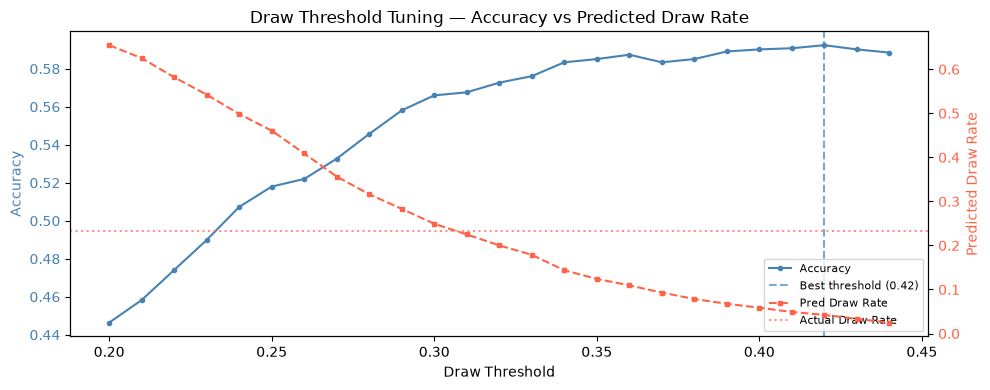


FINAL EVALUATION — draw_threshold = 0.42

 Outcome Accuracy (draw_threshold=0.42) 
  Correct outcome predicted: 59.19%

 Confusion Matrix (rows=actual, cols=predicted)
             Pred HW  Pred Draw  Pred AW
Actual HW        646         26      152
Actual Draw      220         33      160
Actual AW        149         17      371

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.64      0.78      0.70       824
        Draw       0.43      0.08      0.13       413
     AwayWin       0.54      0.69      0.61       537

    accuracy                           0.59      1774
   macro avg       0.54      0.52      0.48      1774
weighted avg       0.56      0.59      0.54      1774



In [23]:
# Threshold tuning plot
fig, ax1 = plt.subplots(figsize=(10, 4))
 
ax1.plot(df_thresh['threshold'], df_thresh['accuracy'],
         color='steelblue', marker='o', markersize=3, label='Accuracy')
ax1.axvline(best_thresh, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Best threshold ({best_thresh:.2f})')
ax1.set_xlabel('Draw Threshold')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
 
ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['pred_draw_rate'],
         color='tomato', marker='s', markersize=3, linestyle='--', label='Pred Draw Rate')
ax2.axhline((valid_preds['result'] == 1).mean(), color='tomato', linestyle=':',
            alpha=0.7, label='Actual Draw Rate')
ax2.set_ylabel('Predicted Draw Rate', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
 
plt.title('Draw Threshold Tuning — Accuracy vs Predicted Draw Rate')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/dc_threshold_tuning.png', dpi=150)
plt.show()
 
 
# Final evaluation with best threshold
print("\n" + "=" * 60)
print(f"FINAL EVALUATION — draw_threshold = {best_thresh:.2f}")
print("=" * 60)
 
evaluate_outcome(valid_preds, draw_threshold=best_thresh)

# Goal Distribution

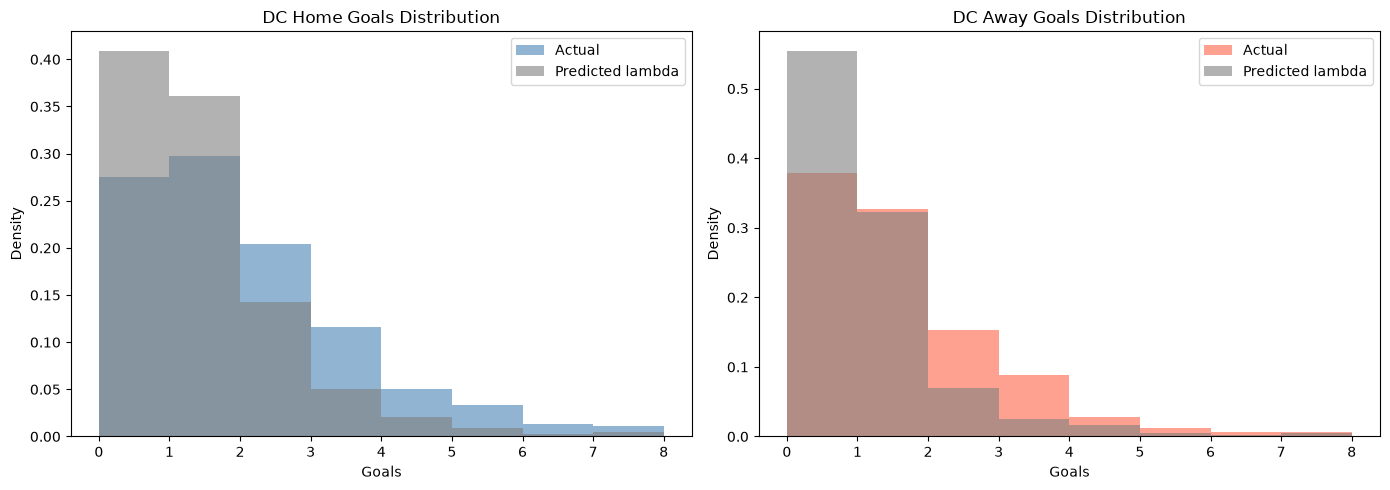

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col_actual, col_pred, title, color in [
    (axes[0], 'home_goals', 'pred_home_goals', 'Home Goals', 'steelblue'),
    (axes[1], 'away_goals', 'pred_away_goals', 'Away Goals', 'tomato'),
]:
    ax.hist(valid_preds[col_actual].clip(0, 7), bins=range(9),
            alpha=0.6, label='Actual', color=color, density=True)
    ax.hist(valid_preds[col_pred].clip(0, 7), bins=range(9),
            alpha=0.6, label='Predicted lambda', color='gray', density=True)
    ax.set_title(f'DC {title} Distribution')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Density')
    ax.legend()
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/dc_goal_distribution.png', dpi=150)
plt.show()

# Team Strength Scatter

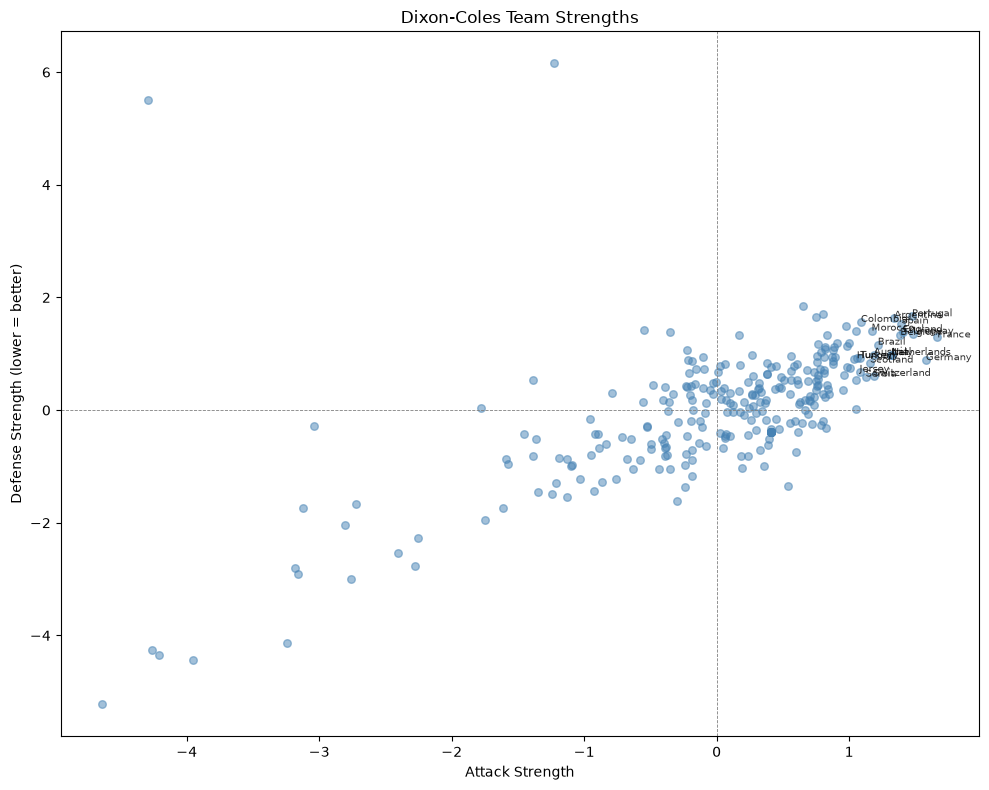

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
 
ax.scatter(df_strength['attack'], df_strength['defense'],
           alpha=0.5, color='steelblue', s=30)
 
for _, row in df_strength.head(20).iterrows():
    ax.annotate(row['team'], (row['attack'], row['defense']), fontsize=7, alpha=0.8)
 
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.6, linestyle='--')
ax.set_xlabel('Attack Strength')
ax.set_ylabel('Defense Strength (lower = better)')
ax.set_title('Dixon-Coles Team Strengths')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/dc_team_strengths.png', dpi=150)
plt.show()

#  Score Probability Heatmap (example match)

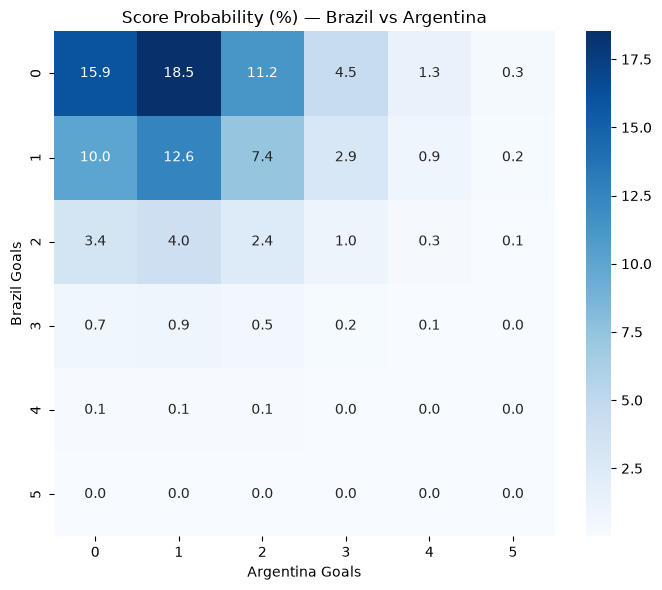


Brazil vs Argentina:
  lambda_home    : 0.6558
  lambda_away    : 1.1971
  P(Home Win)    : 20.03%
  P(Draw)        : 31.12%
  P(Away Win)    : 48.85%


In [26]:
example_home = 'Brazil'
example_away = 'Argentina'
 
try:
    ex = predict_dc(example_home, example_away, is_neutral=True)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        ex['score_matrix'][:6, :6] * 100,
        annot=True, fmt='.1f', cmap='Blues',
        xticklabels=range(6), yticklabels=range(6), ax=ax
    )
    ax.set_xlabel(f'{example_away} Goals')
    ax.set_ylabel(f'{example_home} Goals')
    ax.set_title(f'Score Probability (%) — {example_home} vs {example_away}')
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/dc_score_heatmap.png', dpi=150)
    plt.show()
 
    print(f"\n{example_home} vs {example_away}:")
    print(f"  lambda_home    : {ex['lambda_home']}")
    print(f"  lambda_away    : {ex['lambda_away']}")
    print(f"  P(Home Win)    : {ex['prob_home_win']:.2%}")
    print(f"  P(Draw)        : {ex['prob_draw']:.2%}")
    print(f"  P(Away Win)    : {ex['prob_away_win']:.2%}")
except ValueError as e:
    print(f"Skipping heatmap example: {e}")
 

# Saving the Model 

In [29]:

dc_model = {
    'attack':         {team: float(attack_fit[i])  for team, i in team_index.items()},
    'defense':        {team: float(defense_fit[i]) for team, i in team_index.items()},
    'home_advantage': float(home_adv_fit),
    'rho':            float(rho_fit),
    'all_teams':      all_teams,
}
joblib.dump(dc_model, f'{MODEL_DIR}/dc_model.pkl')


thresh_cfg = {
    'draw_threshold':      float(best_thresh),
    'validation_accuracy': float(best_acc),
    'actual_draw_rate':    round((valid_preds['result'] == 1).mean(), 4),
    'rho':                 float(rho_fit),
}
with open(f'{METRICS_DIR}/dc_threshold.json', 'w') as f:
    json.dump(thresh_cfg, f, indent=2)


df_strength.to_csv(f'{INTERIM_DIR}/dc_team_strengths.csv', index=False)


valid_preds.to_csv(f'{PREDICTIONS_DIR}/dc_valid_preds.csv', index=False)

print("\nSaved:")
print(f"  models/          → dc_model.pkl")
print(f"  metrics/         → dc_threshold.json")
print(f"  interim_data/    → dc_team_strengths.csv")
print(f"  predictions/     → dc_valid_preds.csv")
print(json.dumps(thresh_cfg, indent=2))


Saved:
  models/          → dc_model.pkl
  metrics/         → dc_threshold.json
  interim_data/    → dc_team_strengths.csv
  predictions/     → dc_valid_preds.csv
{
  "draw_threshold": 0.42,
  "validation_accuracy": 0.5924,
  "actual_draw_rate": 0.2328,
  "rho": -0.020019957669734842
}
